In [1]:
import pyEDM
import pandas as pd
import numpy as np
import random
from collections import Counter
random.seed(42)

p22 = pd.read_csv('../data/processed_22.csv')
p23 = pd.read_csv('../data/processed_23.csv')
p24 = pd.read_csv('../data/processed_24.csv')
p25 = pd.read_csv('../data/processed_25.csv')
combined = pd.concat([p22, p23, p24, p25], ignore_index=True)

In [2]:
# top 20 features from paper + target variable + one additional taxa as predictor
features = [
    "Lpoly_expected_ml", "Area", "Biovolume", "MajorAxisLength",
    "MinorAxisLength", "Perimeter", "Orientation", "Eccentricity",
    "Solidity", "texture_uniformity", "texture_smoothness",
    "texture_average_gray_level", "texture_entropy",
    "texture_average_contrast", "H90", "H180", "Hflip",
    "Extent", "EquivDiameter", "ConvexArea", "ConvexPerimeter",
    "Pmicans_expected_ml" # add another taxa as a predictor
]

target = "Lpoly_expected_ml"
predictors = [col for col in features if col != target]

# process images features for MVE
df = combined[["date"] + features].copy()
df["date"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d")
df = df.sort_values("date").set_index("date")
df = df.asfreq("D")

# fill missing values using ema
df_filled = df.copy()
for col in features:
    ema = df[col].ewm(span=30, adjust=False).mean()
    df_filled[col] = df[col].fillna(ema)

# normalize features
df_norm = df_filled.copy()
for col in features:
    mu = df_filled[col].mean()
    sigma = df_filled[col].std()
    df_norm[col] = (df_filled[col] - mu) / sigma

df_mv = df_norm.copy()

In [3]:
# process environmental data
env = pd.read_csv("../data/environment_all.csv")

# could be relevant but too many missing values for ema imputation to be effective
env = env.drop(columns=[
    'fluorescent_dissolved_organic_matter_eco',
    'sea_water_turbidity_eco',
    'waterlevel_predicted_m',
    'mass_concentration_of_oxygen_in_sea_water_seaphox',
    'mole_concentration_of_dissolved_molecular_oxygen_in_sea_water_seaphox',
    'fractional_saturation_of_oxygen_in_sea_water_seaphox',
    'sea_water_ph_reported_on_total_scale_seaphox_external'
])

env["date"] = pd.to_datetime(env["date"].astype(str), format="%Y%m%d")
env = env.sort_values("date").set_index("date")
env = env.asfreq("D")

env_features = env.columns.tolist()
env_filled = env.copy()

# fill missing values using ema
for col in env_features:
    ema = env[col].ewm(span=30, adjust=False).mean()
    env_filled[col] = env[col].fillna(ema)

# normalize features
df_norm = env_filled.copy()
for col in env_features:
    mu = env_filled[col].mean()
    sigma = env_filled[col].std()
    df_norm[col] = (env_filled[col] - mu) / sigma

df_env = df_norm.copy()

In [4]:
# align the two datasets on their common date range
common_start = max(df_mv.index.min(), df_env.index.min())
common_end = min(df_mv.index.max(), df_env.index.max())

df_mv = df_mv.loc[common_start:common_end]
df_env = df_env.loc[common_start:common_end]

df_all = df_mv.merge(df_env,left_index=True,right_index=True,how="inner")
df_all = df_all.reset_index()
df_all["t"] = np.arange(1, len(df_all) + 1)
df_all = df_all[["t"] + features + env_features]

df_mv = df_all[["t"] + features]
df_env = df_all[["t"] + env_features + [target]]

https://sugiharalab.github.io/EDM_Documentation/parameters/

In [5]:
def one_simplex(df, target, features, E=4, Tp=1):
    # Randomly select 3 features (+ the target) for the simplex projection
    chosen_features = random.sample(features, 3)
    columns = [target] + chosen_features
    columns_str = " ".join(columns) # has to be 'space separated' idk ????

    N = len(df)
    res = pyEDM.Simplex(
        dataFrame=df,
        columns=columns_str,
        target=target,
        E=E,
        tau=1,
        Tp=Tp,
        lib=f"1 {N}",
        pred=f"1 {N}"
    )

    obs = res["Observations"].to_numpy()
    pred = res["Predictions"].to_numpy()

    mask = np.isfinite(obs) & np.isfinite(pred)
    obs = obs[mask]
    pred = pred[mask]

    if len(obs) < 10 or np.std(obs) == 0 or np.std(pred) == 0:
        return np.nan, chosen_features

    rho = np.corrcoef(obs, pred)[0, 1]
    rmse = np.sqrt(np.mean((obs - pred) ** 2))
    mae = np.mean(np.abs(obs - pred))
    return rho, rmse, mae, chosen_features

def multiview_big(df, target, features, Tp, n_trials=500):
    results = []

    for i in range(n_trials):
        rho, rmse, mae, chosen = one_simplex(df, target, features, E=4, Tp=Tp)

        results.append({
            "rho": rho,
            "rmse": rmse,
            "mae": mae,
            "features": chosen
        })

    return pd.DataFrame(results)

def multiview_yes(df_mv, target, predictors):
    # wrapper main function
    x = df_mv[target].to_numpy()

    summary_rows = []
    feature_importance_by_tp = {}
    
    for Tp in range(1, 32):
        mv = multiview_big(df_mv, target, predictors, Tp, n_trials=500)

        acf = abs(pd.Series(x).autocorr(lag=Tp))
        mv["rho_eff"] = mv["rho"] - acf

        # summary stats
        summary_rows.append({
            "Tp": Tp,
            "rho_mean": mv["rho"].mean(),
            "acf": acf,
            "rho_eff_mean": mv["rho_eff"].mean(),
            "rmse_mean": mv["rmse"].mean(),
            "mae_mean": mv["mae"].mean(),
            "n_models": len(mv)
        })

        # feature importance (top 5%)
        top = mv.nlargest(int(0.05 * len(mv)), "rho_eff")

        counts = Counter()
        for feats in top["features"]:
            for f in feats:
                counts[f] += 1

        importance = pd.Series(counts) / len(top)
        feature_importance_by_tp[Tp] = importance.sort_values(ascending=False)
    
    return summary_rows, feature_importance_by_tp

##### Image Features

In [6]:
summary_rows_img = []
feature_importance_by_tp_img = {}

summary_rows_img, feature_importance_by_tp_img = multiview_yes(df_mv, target, predictors)
summary_df_img = pd.DataFrame(summary_rows_img)
print(summary_df_img)

    Tp  rho_mean       acf  rho_eff_mean  rmse_mean  mae_mean  n_models
0    1  0.940135  0.750836      0.189300   0.439333  0.083295       500
1    2  0.949407  0.507478      0.441930   0.402746  0.078743       500
2    3  0.948128  0.363468      0.584661   0.377946  0.080308       500
3    4  0.594056  0.323560      0.270496   0.810557  0.181759       500
4    5  0.407290  0.282526      0.124765   0.945784  0.217034       500
5    6  0.365037  0.199548      0.165490   0.964105  0.225539       500
6    7  0.303833  0.162179      0.141655   0.982039  0.237566       500
7    8  0.239517  0.160931      0.078586   0.999675  0.240159       500
8    9  0.249507  0.149251      0.100256   0.998083  0.240002       500
9   10  0.253443  0.174992      0.078451   0.996177  0.243209       500
10  11  0.232610  0.157892      0.074718   1.004961  0.248176       500
11  12  0.198242  0.141327      0.056915   1.027203  0.266158       500
12  13  0.167349  0.147118      0.020231   1.045240  0.279247   

In [7]:
importance_all_img = pd.concat(
    feature_importance_by_tp_img,
    names=["Tp", "Feature"]
).reset_index()

importance_all_img.columns = ["Tp", "Feature", "Proportion"]
# print(importance_all_img)

##### Environmental Features

In [8]:
summary_rows_env = []
feature_importance_by_tp_env = {}

summary_rows_env, feature_importance_by_tp_env = multiview_yes(df_env, target, env_features)
summary_df_env = pd.DataFrame(summary_rows_env)
print(summary_df_env)

    Tp  rho_mean       acf  rho_eff_mean  rmse_mean  mae_mean  n_models
0    1  0.931405  0.750836      0.180569   0.454534  0.117685       500
1    2  0.940564  0.507478      0.433086   0.422759  0.114105       500
2    3  0.938100  0.363468      0.574632   0.403248  0.116224       500
3    4  0.585259  0.323560      0.261699   0.816943  0.203395       500
4    5  0.407409  0.282526      0.124883   0.937718  0.230190       500
5    6  0.403666  0.199548      0.204118   0.933138  0.233785       500
6    7  0.419638  0.162179      0.257459   0.912645  0.234415       500
7    8  0.384688  0.160931      0.223757   0.924238  0.246464       500
8    9  0.399290  0.149251      0.250039   0.914903  0.245847       500
9   10  0.351655  0.174992      0.176663   0.948552  0.258896       500
10  11  0.313284  0.157892      0.155392   0.975225  0.266023       500
11  12  0.259969  0.141327      0.118642   1.016911  0.282139       500
12  13  0.244283  0.147118      0.097165   1.015934  0.286124   

In [9]:
importance_all_env = pd.concat(
    feature_importance_by_tp_env,
    names=["Tp", "Feature"]
).reset_index()

importance_all_env.columns = ["Tp", "Feature", "Proportion"]
# print(importance_all_env)

##### Combined

In [10]:
summary_rows_com = []
feature_importance_by_tp_com = {}

summary_rows_com, feature_importance_by_tp_com = multiview_yes(df_all, target, predictors+env_features)
summary_df_com = pd.DataFrame(summary_rows_com)
print(summary_df_com)

    Tp  rho_mean       acf  rho_eff_mean  rmse_mean  mae_mean  n_models
0    1  0.936837  0.750836      0.186001   0.444857  0.093238       500
1    2  0.946563  0.507478      0.439085   0.409682  0.088733       500
2    3  0.944369  0.363468      0.580901   0.387618  0.091375       500
3    4  0.586525  0.323560      0.262965   0.816639  0.187866       500
4    5  0.400170  0.282526      0.117644   0.947959  0.220341       500
5    6  0.362330  0.199548      0.162782   0.962918  0.227574       500
6    7  0.328958  0.162179      0.166779   0.967700  0.234686       500
7    8  0.269146  0.160931      0.108215   0.986920  0.240219       500
8    9  0.282196  0.149251      0.132945   0.980031  0.237703       500
9   10  0.279571  0.174992      0.104579   0.982762  0.241501       500
10  11  0.265976  0.157892      0.108084   0.989195  0.246067       500
11  12  0.257380  0.141327      0.116053   1.000947  0.260466       500
12  13  0.255297  0.147118      0.108180   1.001673  0.268378   

In [11]:
importance_all_com = pd.concat(
    feature_importance_by_tp_com,
    names=["Tp", "Feature"]
).reset_index()

importance_all_com.columns = ["Tp", "Feature", "Proportion"]
# print(importance_all_com)

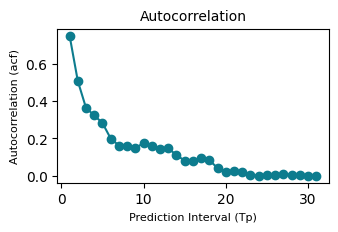

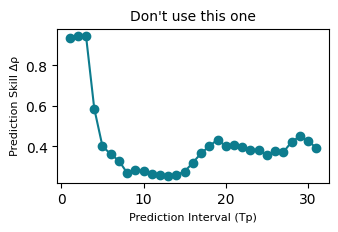

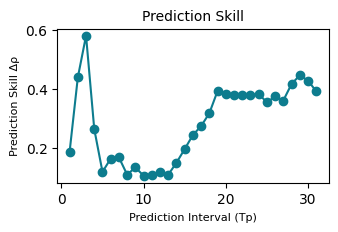

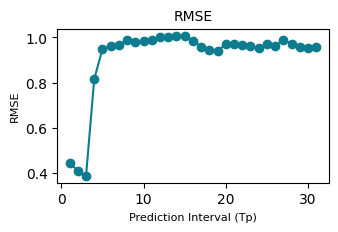

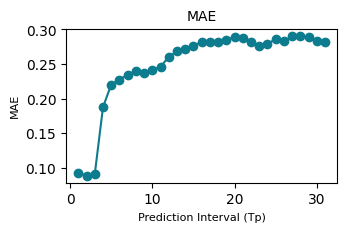

In [12]:
import matplotlib.pyplot as plt

# acf over tp
plt.figure(figsize=(3.5, 2))
plt.plot(summary_df_com["Tp"], summary_df_com["acf"], marker="o", color="#0d7c8e")
plt.xlabel("Prediction Interval (Tp)", fontsize=8)
plt.ylabel("Autocorrelation (acf)", fontsize=8)
plt.title("Autocorrelation", fontsize=10)
plt.show()

# rho_mean over tp (don't use this one) includes autocorrelation bias
plt.figure(figsize=(3.5, 2))
plt.plot(summary_df_com["Tp"], summary_df_com["rho_mean"], marker="o", color="#0d7c8e")
plt.xlabel("Prediction Interval (Tp)", fontsize=8)
plt.ylabel("Prediction Skill Δρ", fontsize=8)
plt.title("Don't use this one", fontsize=10)
plt.show()

# rho_eff_mean over tp
plt.figure(figsize=(3.5, 2))
plt.plot(summary_df_com["Tp"], summary_df_com["rho_eff_mean"], marker="o", color="#0d7c8e")
plt.xlabel("Prediction Interval (Tp)", fontsize=8)
plt.ylabel("Prediction Skill Δρ", fontsize=8)
plt.title("Prediction Skill", fontsize=10)
plt.show()

# rmse_mean over tp
plt.figure(figsize=(3.5, 2))
plt.plot(summary_df_com["Tp"], summary_df_com["rmse_mean"], marker="o", color="#0d7c8e")
plt.xlabel("Prediction Interval (Tp)", fontsize=8)
plt.ylabel("RMSE", fontsize=8)
plt.title("RMSE", fontsize=10)
plt.show()

# mae_mean over tp
plt.figure(figsize=(3.5, 2))
plt.plot(summary_df_com["Tp"], summary_df_com["mae_mean"], marker="o", color="#0d7c8e")
plt.xlabel("Prediction Interval (Tp)", fontsize=8)
plt.ylabel("MAE", fontsize=8)
plt.title("MAE", fontsize=10)
plt.show()

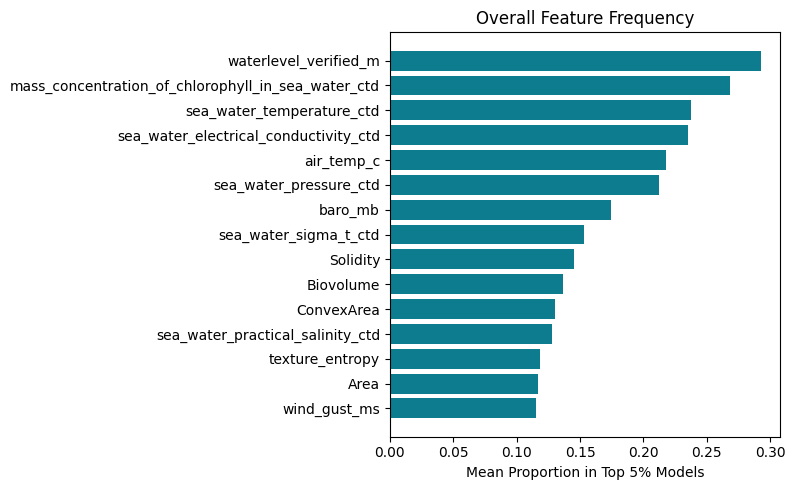

In [13]:
mean_importance = (
    importance_all_com
    .groupby("Feature")["Proportion"]
    .mean()
    .sort_values(ascending=False)
)

top_plot = mean_importance.head(15).sort_values()

plt.figure(figsize=(8,5))
plt.barh(top_plot.index, top_plot.values, color="#0d7c8e")
plt.xlabel("Mean Proportion in Top 5% Models")
plt.title("Overall Feature Frequency")
plt.tight_layout()
plt.show()

^^ using combined